In [ ]:
# @title SPECTRE vs Vanilla PE – Clean vs Typo Shakespeare
# Upload the zip, unzip, then run all cells.

# The SPECTRE.zip file has already been unzipped and its contents moved to /content/
# Therefore, the following unzip and cd commands are not needed.
# !unzip -o spectre_typo_test.zip -d spectre_typo_test
# %cd spectre_typo_test

!pip -q install -r requirements.txt

# Download original Shakespeare if not present
import os, urllib
if not os.path.exists('data/input.txt'):
    os.makedirs('data', exist_ok=True)
    url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    urllib.request.urlretrieve(url, 'data/input.txt')

In [ ]:
# Generate typo version
!python generate_typo.py data/input.txt data/input_typo.txt

Generated data/input_typo.txt


In [ ]:
# Run on clean data (both arms)
!python train.py --arm both --data data/input.txt --iters 3000 --dmodel 512 --nhead 16 --K 32
# This will produce results_clean.json and curves_clean.png

device: cuda
vocab 14297 | corpus 253599 tokens | len p50=7 p99=12 p999=14 max=16
[vanilla] trainable params: 19.93M (spectre L_max=-)
[vanilla] iter   100  val 27.4653  (10s)
[vanilla] iter   200  val 13.8374  (20s)
[vanilla] iter   300  val 10.7416  (31s)
[vanilla] iter   400  val 10.5608  (42s)
[vanilla] iter   500  val 10.0720  (53s)
[vanilla] iter   600  val 9.1033  (65s)
[vanilla] iter   700  val 8.4752  (77s)
[vanilla] iter   800  val 8.0606  (88s)
[vanilla] iter   900  val 7.7476  (100s)
[vanilla] iter  1000  val 7.5281  (111s)
[vanilla] iter  1100  val 7.3741  (122s)
[vanilla] iter  1200  val 7.2106  (133s)
[vanilla] iter  1300  val 7.1531  (145s)
[vanilla] iter  1400  val 7.0733  (156s)
[vanilla] iter  1500  val 6.9935  (168s)
[vanilla] iter  1600  val 6.9521  (179s)
[vanilla] iter  1700  val 6.8599  (191s)
[vanilla] iter  1800  val 6.7851  (202s)
[vanilla] iter  1900  val 6.8007  (214s)
[vanilla] iter  2000  val 6.7823  (225s)
[vanilla] iter  2100  val 6.7248  (236s)
[vanill

In [ ]:
# Rename results to avoid overwrite
!mv results.json results_clean.json
!mv curves.png curves_clean.png

In [ ]:

# Run on typo data
!python train.py --arm both --data data/input_typo.txt --iters 3000 --dmodel 512 --nhead 16 --K 32
# This will produce results_typo.json and curves.png


device: cuda
vocab 23325 | corpus 253465 tokens | len p50=6 p99=12 p999=14 max=16
[vanilla] trainable params: 24.55M (spectre L_max=-)
[vanilla] iter   100  val 30.2543  (14s)
[vanilla] iter   200  val 16.3542  (28s)
[vanilla] iter   300  val 14.0336  (42s)
[vanilla] iter   400  val 11.7714  (56s)
[vanilla] iter   500  val 10.2974  (70s)
[vanilla] iter   600  val 9.4366  (84s)
[vanilla] iter   700  val 8.9704  (98s)
[vanilla] iter   800  val 8.7235  (112s)
[vanilla] iter   900  val 8.4602  (126s)
[vanilla] iter  1000  val 8.2065  (140s)
[vanilla] iter  1100  val 8.0611  (154s)
[vanilla] iter  1200  val 7.9907  (168s)
[vanilla] iter  1300  val 7.8551  (182s)
[vanilla] iter  1400  val 7.7584  (196s)
[vanilla] iter  1500  val 7.6905  (210s)
[vanilla] iter  1600  val 7.6388  (224s)
[vanilla] iter  1700  val 7.5968  (238s)
[vanilla] iter  1800  val 7.6217  (252s)
[vanilla] iter  1900  val 7.5395  (266s)
[vanilla] iter  2000  val 7.5274  (280s)
[vanilla] iter  2100  val 7.5063  (294s)
[vanil

In [ ]:
!mv results.json results_typo.json
!mv curves.png curves_typo.png


In [ ]:

# Plot comparison side‑by‑side
import json, matplotlib.pyplot as plt

def load_curves(fname):
    with open(fname) as f:
        d = json.load(f)
    return d

In [ ]:
clean = load_curves('results_clean.json')
typo = load_curves('results_typo.json')

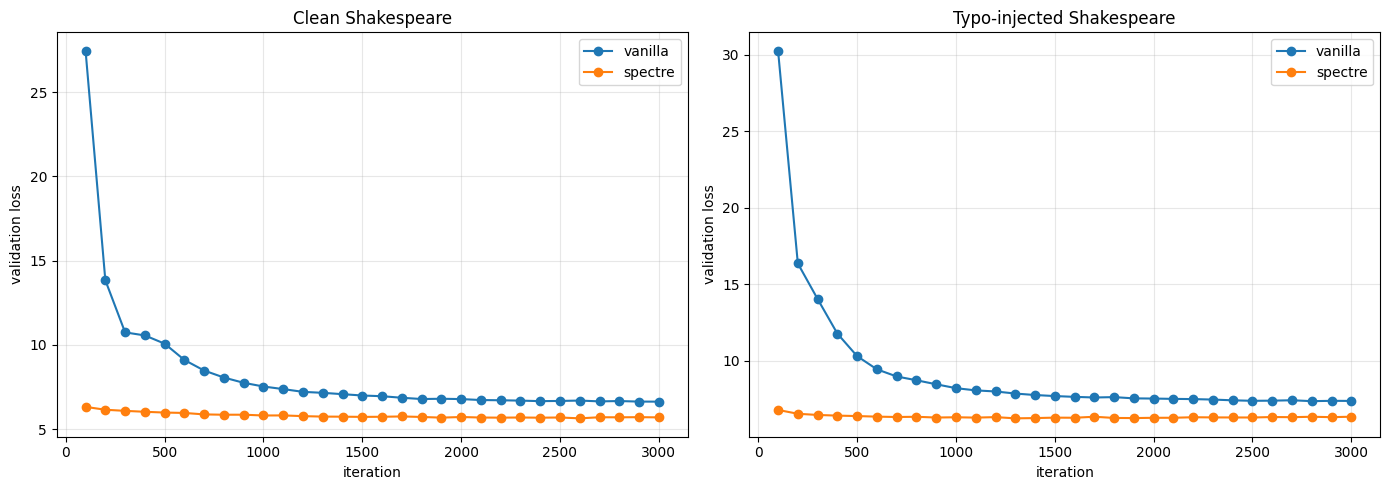

Done! Check comparison.png and the .json files for exact numbers.


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14,5))
for ax, data, title in zip(axes, [clean, typo], ['Clean Shakespeare', 'Typo‑injected Shakespeare']):
    for arm, hist in data.items():
        ax.plot(hist['iter'], hist['val'], marker='o', label=arm)
    ax.set_xlabel('iteration')
    ax.set_ylabel('validation loss')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('comparison.png', dpi=150)
plt.show()

print("Done! Check comparison.png and the .json files for exact numbers.")


In [ ]:
# # =============================================================================
# # SPECTRE Grid Search – Clean vs Typo, multiple model sizes
# # =============================================================================
# # Paste this into a Colab cell *after* the usual unzip/install steps.
# # It runs train.py repeatedly with different --dmodel and --nhead values.
# # -----------------------------------------------------------------------------
# # WARNING: 4 dmodels × 3 nheads × 2 datasets = 24 training runs.
# # At 1500 iters each, this will take several hours on a T4.
# # Reduce ITERS or filter combos below if you want a quicker test.
# # =============================================================================

# import json
# import os
# import time

# # -----------------------------------------------------------------------------
# # USER CONFIG
# # -----------------------------------------------------------------------------
# ITERS = 1500               # steps per run (use 3000 if you have time)
# K_LENSES = 16              # number of SPECTRE lenses (fixed for this sweep)

# # Hyper‑parameter grid
# DMODELS = [192, 256, 384, 512]
# NHEADS = [4, 8, 16]

# # Build valid combinations (d_model must be divisible by n_head)
# combos = [(d, h) for d in DMODELS for h in NHEADS if d % h == 0]
# print(f"Will run {len(combos)} combinations × 2 datasets = {len(combos)*2} training jobs.")
# print("Combinations:", combos)

# # -----------------------------------------------------------------------------
# # Runner
# # -----------------------------------------------------------------------------
# summary = []
# header = (
#     "dmodel\tnheads\t"
#     "clean_vanilla\tclean_spectre\tclean_delta\t"
#     "typo_vanilla\ttypo_spectre\ttypo_delta"
# )
# summary.append(header)

# for d, h in combos:
#     print(f"\n{'='*60}")
#     print(f"d_model={d}, n_head={h}")
#     print('='*60)

#     # ----- 1. Clean data -----
#     print("\n[1/2] Training on CLEAN Shakespeare...")
#     !python train.py --arm both --data data/input.txt \
#                      --iters {ITERS} --dmodel {d} --nhead {h} --K {K_LENSES} \
#                      --eval_every 200 --seed 1337

#     with open('results.json', 'r') as f:
#         clean_data = json.load(f)
#     clean_van = clean_data['vanilla']['val'][-1]
#     clean_spec = clean_data['spectre']['val'][-1]
#     clean_delta = clean_van - clean_spec
#     print(f"Clean → vanilla: {clean_van:.4f}, spectre: {clean_spec:.4f}, delta: {clean_delta:.4f}")

#     # ----- 2. Typo data -----
#     print("\n[2/2] Training on TYPO Shakespeare...")
#     !python train.py --arm both --data data/input_typo.txt \
#                      --iters {ITERS} --dmodel {d} --nhead {h} --K {K_LENSES} \
#                      --eval_every 200 --seed 1337

#     with open('results.json', 'r') as f:
#         typo_data = json.load(f)
#     typo_van = typo_data['vanilla']['val'][-1]
#     typo_spec = typo_data['spectre']['val'][-1]
#     typo_delta = typo_van - typo_spec
#     print(f"Typo  → vanilla: {typo_van:.4f}, spectre: {typo_spec:.4f}, delta: {typo_delta:.4f}")

#     # ----- Save row -----
#     row = f"{d}\t{h}\t{clean_van:.4f}\t{clean_spec:.4f}\t{clean_delta:.4f}\t{typo_van:.4f}\t{typo_spec:.4f}\t{typo_delta:.4f}"
#     summary.append(row)

#     # Write progress to disk (overwrites each time, keeps latest)
#     with open('spectre_grid_summary.txt', 'w') as f:
#         f.write("\n".join(summary))

# print("\n" + "="*60)
# print("GRID SEARCH COMPLETE.")
# print(f"Summary saved to spectre_grid_summary.txt")
# print("\nFinal summary:")
# print("\n".join(summary))